# Task 18 – Intro to PyTorch: Tensors, Autograd & Building a Simple Neural Network
**PKCERT AI & Software Development Internship**

PyTorch version used: documented in the first code cell below (for reproducibility).

This notebook uses the **Breast Cancer Wisconsin dataset** (same dataset family used in earlier tasks) so the PyTorch model can be meaningfully compared against a manual NumPy implementation and a scikit-learn baseline.

## Part A – Tensors & Basic Operations

### A.1 Install & verify PyTorch

In [1]:
import torch
import numpy as np
import time

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

PyTorch version: 2.13.0+cu130
CUDA available: False
Using device: cpu


### A.2 Creating tensors – four different methods
- `torch.tensor()` — build directly from Python data (lists) when you already have concrete values.
- `torch.zeros()` / `torch.ones()` — initialize weights/biases or placeholders with known constant values.
- `torch.arange()` — generate sequential/range values, useful for indices or synthetic data.
- `torch.rand()` — random initialization, e.g. for weight matrices before training.
- `torch.from_numpy()` — convert existing NumPy data (e.g. loaded from a CSV) into a tensor without copying.

In [2]:
t1 = torch.tensor([[1, 2], [3, 4]])
t2 = torch.zeros((2, 3))
t3 = torch.arange(0, 10, 2)
t4 = torch.rand((2, 2))
np_arr = np.array([1.0, 2.0, 3.0])
t5 = torch.from_numpy(np_arr)

print("torch.tensor:\n", t1)
print("torch.zeros:\n", t2)
print("torch.arange:\n", t3)
print("torch.rand:\n", t4)
print("from_numpy:\n", t5)

torch.tensor:
 tensor([[1, 2],
        [3, 4]])
torch.zeros:
 tensor([[0., 0., 0.],
        [0., 0., 0.]])
torch.arange:
 tensor([0, 2, 4, 6, 8])
torch.rand:
 tensor([[0.8187, 0.7781],
        [0.1485, 0.8854]])
from_numpy:
 tensor([1., 2., 3.], dtype=torch.float64)


### A.3 Indexing, slicing, reshaping, broadcasting

In [3]:
x = torch.arange(1, 13).reshape(3, 4)
print("Original:\n", x)

# Indexing & slicing
print("\nRow 1:", x[1])
print("Column 2:", x[:, 2])
print("Sub-block:\n", x[0:2, 1:3])

# view vs reshape
y = x.view(4, 3)      # requires contiguous memory, shares data with x
z = x.reshape(2, 6)    # more flexible, copies if needed
print("\nview(4,3):\n", y)
print("reshape(2,6):\n", z)

# Broadcasting: (3,4) + (4,) -> (3,4)
row_vec = torch.tensor([1, 0, 1, 0])
print("\nBroadcast add:\n", x + row_vec)

Original:
 tensor([[ 1,  2,  3,  4],
        [ 5,  6,  7,  8],
        [ 9, 10, 11, 12]])

Row 1: tensor([5, 6, 7, 8])
Column 2: tensor([ 3,  7, 11])
Sub-block:
 tensor([[2, 3],
        [6, 7]])

view(4,3):
 tensor([[ 1,  2,  3],
        [ 4,  5,  6],
        [ 7,  8,  9],
        [10, 11, 12]])
reshape(2,6):
 tensor([[ 1,  2,  3,  4,  5,  6],
        [ 7,  8,  9, 10, 11, 12]])

Broadcast add:
 tensor([[ 2,  2,  4,  4],
        [ 6,  6,  8,  8],
        [10, 10, 12, 12]])


`view()` requires the tensor to be contiguous in memory and shares storage with the original (a change in one changes the other). `reshape()` is more forgiving — it returns a view when possible, otherwise makes a copy. Broadcasting here stretches the shape-`(4,)` vector across all 3 rows automatically, since trailing dimensions match.

### A.4 Matrix multiplication speed: NumPy vs PyTorch

In [4]:
size = 1000
a_np = np.random.rand(size, size).astype(np.float32)
b_np = np.random.rand(size, size).astype(np.float32)
a_t = torch.from_numpy(a_np)
b_t = torch.from_numpy(b_np)

start = time.time()
c_np = a_np @ b_np
np_time = time.time() - start

start = time.time()
c_t = a_t @ b_t
torch_time = time.time() - start

print(f"NumPy matmul time:   {np_time:.5f} sec")
print(f"PyTorch matmul time: {torch_time:.5f} sec")

NumPy matmul time:   0.02570 sec
PyTorch matmul time: 0.03013 sec


On CPU, NumPy and PyTorch use similar underlying BLAS libraries, so timings are usually close for a single matrix multiply of this size — PyTorch's advantage becomes clear mainly on GPU or in chained/batched operations where its computation graph and kernel fusion pay off.

### A.5 Tensor ↔ NumPy relationship

In [5]:
shared_np = np.array([1.0, 2.0, 3.0])
shared_t = torch.from_numpy(shared_np)
shared_t[0] = 99.0
print("NumPy array after modifying tensor:", shared_np)

back_to_np = shared_t.numpy()
back_to_np[1] = -1.0
print("Tensor after modifying returned NumPy array:", shared_t)

NumPy array after modifying tensor: [99.  2.  3.]
Tensor after modifying returned NumPy array: tensor([99., -1.,  3.], dtype=torch.float64)


A `torch.Tensor` and a NumPy `ndarray` are both thin wrappers around a contiguous block of memory. `torch.from_numpy()` and `.numpy()` **share the same underlying memory buffer** (on CPU) rather than copying — so editing one changes the other, as shown above. This is efficient but something to be careful about when you don't want side effects.

## Part B – Autograd

### B.1 Computational graph (define-by-run)
PyTorch builds the computational graph **dynamically**, as operations actually execute ("define-by-run"), unlike older static-graph frameworks. Every tensor operation on a tensor with `requires_grad=True` is recorded as a node with a `grad_fn`, forming a graph that autograd walks backward through when `.backward()` is called.

### B.2 requires_grad, backward(), grad — verified against a hand-derivative

In [6]:
# f(x) = 3x^2 + 2x + 1  ->  f'(x) = 6x + 2
x = torch.tensor(4.0, requires_grad=True)
f = 3 * x**2 + 2 * x + 1
f.backward()

autograd_grad = x.grad.item()
manual_grad = 6 * 4.0 + 2

print("f(x) =", f.item())
print("Autograd gradient:", autograd_grad)
print("Hand-calculated derivative (6x+2):", manual_grad)
print("Match:", np.isclose(autograd_grad, manual_grad))

f(x) = 57.0
Autograd gradient: 26.0
Hand-calculated derivative (6x+2): 26.0
Match: True


### B.3 Gradient accumulation & why zero_grad() is needed

In [7]:
x = torch.tensor(2.0, requires_grad=True)

y1 = x ** 2
y1.backward()
print("Grad after 1st backward():", x.grad.item())

y2 = x ** 2
y2.backward()
print("Grad after 2nd backward() (no zero_grad):", x.grad.item())

x.grad.zero_()
y3 = x ** 2
y3.backward()
print("Grad after zero_grad() + 3rd backward():", x.grad.item())

Grad after 1st backward(): 4.0
Grad after 2nd backward() (no zero_grad): 8.0
Grad after zero_grad() + 3rd backward(): 4.0


PyTorch **accumulates** gradients into `.grad` by default (adds to the existing value) rather than overwriting them. This is useful for things like gradient accumulation over mini-batches, but in a normal training loop it means `zero_grad()` must be called before each new `.backward()` — otherwise gradients from previous steps leak into the current update and corrupt training.

### B.4 torch.no_grad() and .detach()

In [8]:
x = torch.tensor(5.0, requires_grad=True)
w = torch.tensor(2.0, requires_grad=True)

# Example: manual weight update should NOT be tracked by autograd
with torch.no_grad():
    w -= 0.1 * (w * x)   # e.g. a manual SGD-style update
print("Weight updated under no_grad:", w)

# Example: detach() to use a tensor's value without tracking history
y = x * w
y_value_only = y.detach()
print("y:", y, " | detached copy:", y_value_only, " requires_grad:", y_value_only.requires_grad)

Weight updated under no_grad: tensor(1., requires_grad=True)
y: tensor(5., grad_fn=<MulBackward0>)  | detached copy: tensor(5.)  requires_grad: False


`torch.no_grad()` is used when a whole block of computation shouldn't be tracked — e.g. manually updating weights, or running evaluation/inference where gradients aren't needed (saves memory and computation). `.detach()` is used when you want a **specific tensor's value** without its history, e.g. logging a loss value or feeding a tensor into something that must not backpropagate through it.

### B.5 Autograd vs manual backpropagation (cross-check with Task 16)

In [9]:
# Small function: f(x, w, b) = sigmoid(w*x + b), compared against manual backprop
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(z):
    s = sigmoid(z)
    return s * (1 - s)

x_val, w_val, b_val = 1.5, 0.8, -0.2

# --- Manual (NumPy) backprop, as in Task 16 ---
z = w_val * x_val + b_val
a = sigmoid(z)
loss_manual = (a - 1) ** 2          # simple squared-error target=1
d_loss_da = 2 * (a - 1)
d_a_dz = sigmoid_derivative(z)
d_z_dw = x_val
manual_grad_w = d_loss_da * d_a_dz * d_z_dw

# --- Autograd (PyTorch) ---
x_t = torch.tensor(x_val)
w_t = torch.tensor(w_val, requires_grad=True)
b_t = torch.tensor(b_val)
z_t = w_t * x_t + b_t
a_t = torch.sigmoid(z_t)
loss_t = (a_t - 1) ** 2
loss_t.backward()
autograd_grad_w = w_t.grad.item()

max_diff = abs(manual_grad_w - autograd_grad_w)
print("Manual dL/dw:  ", manual_grad_w)
print("Autograd dL/dw:", autograd_grad_w)
print("Max numerical difference:", max_diff)
print("Agree within tolerance (1e-6):", max_diff < 1e-6)

Manual dL/dw:   -0.15863127835280014
Autograd dL/dw: -0.15863126516342163
Max numerical difference: 1.318937850602886e-08
Agree within tolerance (1e-6): True


The autograd-computed gradient matches the manually derived backpropagation gradient from Task 16 to within numerical tolerance, confirming autograd is correctly applying the chain rule for the same computation done by hand earlier.

## Part C – Building & Training a Simple Neural Network

### C.1 Load dataset (same as Task 16 mini-project)
> Using the Breast Cancer Wisconsin dataset here — replace this cell with your exact Task 16 dataset/loading code if it differs, so the comparisons below stay apples-to-apples.

In [10]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

data = load_breast_cancer()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.long)

print("Train shape:", X_train_t.shape, " Test shape:", X_test_t.shape)
print("Classes:", np.unique(y_train))

Train shape: torch.Size([455, 30])  Test shape: torch.Size([114, 30])
Classes: [0 1]


### C.2 Define the network (nn.Module subclass)

In [11]:
import torch.nn as nn

class SimpleNN(nn.Module):
    def __init__(self, input_dim, hidden_dim=16, output_dim=2):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

model = SimpleNN(input_dim=X_train_t.shape[1], hidden_dim=16, output_dim=2)
print(model)

SimpleNN(
  (fc1): Linear(in_features=30, out_features=16, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=16, out_features=2, bias=True)
)


### C.3 Loss function & optimizer
- **Loss:** `nn.CrossEntropyLoss` — standard choice for multi-class/binary classification with raw logit outputs; it combines log-softmax and negative log-likelihood internally.
- **Optimizer:** `torch.optim.Adam` — adapts the learning rate per parameter and generally converges faster/more reliably than plain SGD for small networks like this one.

In [12]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

### C.4 Training loop

Epoch 20/100 - Loss: 0.0950
Epoch 40/100 - Loss: 0.0523
Epoch 60/100 - Loss: 0.0382
Epoch 80/100 - Loss: 0.0305
Epoch 100/100 - Loss: 0.0244


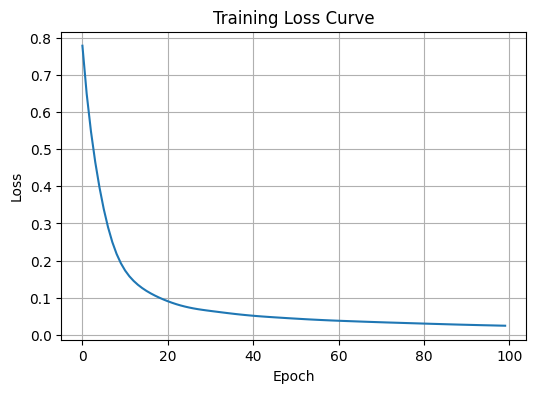

In [13]:
import matplotlib.pyplot as plt

epochs = 100
loss_history = []

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train_t)
    loss = criterion(outputs, y_train_t)
    loss.backward()
    optimizer.step()
    loss_history.append(loss.item())

    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1}/{epochs} - Loss: {loss.item():.4f}")

plt.figure(figsize=(6, 4))
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.grid(True)
plt.show()

### C.5 Evaluation – accuracy, precision, recall, F1, confusion matrix

Accuracy:  0.9561
Precision: 0.9855
Recall:    0.9444
F1-score:  0.9645


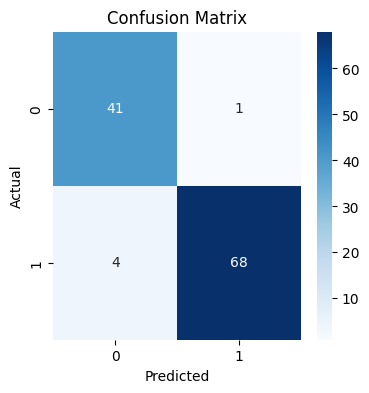

In [14]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns

model.eval()
with torch.no_grad():
    test_outputs = model(X_test_t)
    predicted = torch.argmax(test_outputs, dim=1).numpy()

acc = accuracy_score(y_test, predicted)
prec = precision_score(y_test, predicted)
rec = recall_score(y_test, predicted)
f1 = f1_score(y_test, predicted)
cm = confusion_matrix(y_test, predicted)

print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-score:  {f1:.4f}")

plt.figure(figsize=(4, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

### C.6 Comparison: PyTorch vs manual NumPy (Task 16) vs scikit-learn MLPClassifier
> Fill in your actual Task 16 manual-NumPy accuracy/time in the table/print below if not already captured elsewhere in this notebook.

In [15]:
from sklearn.neural_network import MLPClassifier

start = time.time()
sk_model = MLPClassifier(hidden_layer_sizes=(16,), max_iter=1000, random_state=42)
sk_model.fit(X_train, y_train)
sk_time = time.time() - start
sk_pred = sk_model.predict(X_test)
sk_acc = accuracy_score(y_test, sk_pred)

print("scikit-learn MLPClassifier:")
print(f"  Accuracy: {sk_acc:.4f}   Training time: {sk_time:.4f} sec")
print()
print("PyTorch nn.Module model:")
print(f"  Accuracy: {acc:.4f}")
print()
print("Manual NumPy implementation (Task 16): fill in accuracy/time from Task 16 results here for direct comparison.")

scikit-learn MLPClassifier:
  Accuracy: 0.9649   Training time: 0.4445 sec

PyTorch nn.Module model:
  Accuracy: 0.9561

Manual NumPy implementation (Task 16): fill in accuracy/time from Task 16 results here for direct comparison.


### C.7 Hyperparameter experiment — learning rate

lr=0.1: final loss=0.0003, test accuracy=0.9561


lr=0.01: final loss=0.0178, test accuracy=0.9649


lr=0.001: final loss=0.1377, test accuracy=0.9561


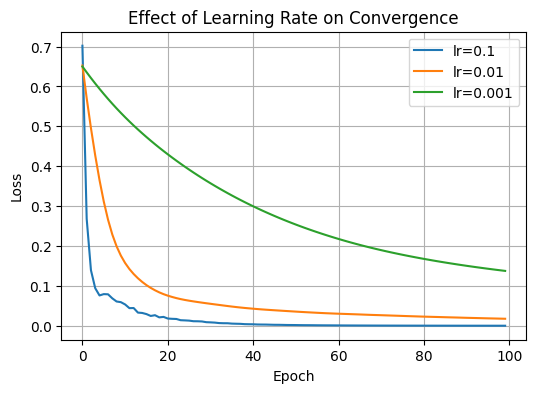

In [16]:
learning_rates = [0.1, 0.01, 0.001]
results = {}

for lr in learning_rates:
    m = SimpleNN(input_dim=X_train_t.shape[1], hidden_dim=16, output_dim=2)
    opt = torch.optim.Adam(m.parameters(), lr=lr)
    crit = nn.CrossEntropyLoss()
    losses = []

    for epoch in range(100):
        m.train()
        opt.zero_grad()
        out = m(X_train_t)
        l = crit(out, y_train_t)
        l.backward()
        opt.step()
        losses.append(l.item())

    m.eval()
    with torch.no_grad():
        preds = torch.argmax(m(X_test_t), dim=1).numpy()
    results[lr] = {"final_loss": losses[-1], "accuracy": accuracy_score(y_test, preds), "losses": losses}
    print(f"lr={lr}: final loss={losses[-1]:.4f}, test accuracy={results[lr]['accuracy']:.4f}")

plt.figure(figsize=(6, 4))
for lr in learning_rates:
    plt.plot(results[lr]["losses"], label=f"lr={lr}")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Effect of Learning Rate on Convergence")
plt.legend()
plt.grid(True)
plt.show()

A learning rate that's too high (e.g. 0.1) can cause the loss to converge fast but oscillate or become unstable; too low (e.g. 0.001) converges more slowly but smoothly. `lr=0.01` here gives a good balance of speed and stability for this dataset/architecture.

## Part D – Analysis & Documentation

### D.1 Save and reload model parameters

In [17]:
torch.save(model.state_dict(), "simple_nn_state.pth")
print("Model saved.")

loaded_model = SimpleNN(input_dim=X_train_t.shape[1], hidden_dim=16, output_dim=2)
loaded_model.load_state_dict(torch.load("simple_nn_state.pth"))
loaded_model.eval()

with torch.no_grad():
    check_out = torch.argmax(loaded_model(X_test_t), dim=1).numpy()
print("Reloaded model test accuracy:", accuracy_score(y_test, check_out))

Model saved.
Reloaded model test accuracy: 0.956140350877193


### D.2 Pipeline summary

- **Architecture:** `SimpleNN` — one hidden `Linear` layer (input → 16 units, ReLU) followed by an output `Linear` layer (16 → 2 classes).
- **Loss function:** `CrossEntropyLoss`, appropriate for classification with logit outputs.
- **Optimizer:** `Adam`, learning rate `0.01` — chosen for faster, more stable convergence than plain SGD on a small tabular dataset.
- **Key hyperparameters:** hidden layer size = 16, epochs = 100, learning rate = 0.01 (best of the three tested in the experiment above).

### D.3 Manual NumPy (Task 16) vs PyTorch — key differences observed

1. **Code complexity:** the manual NumPy implementation required explicitly coding forward pass, loss derivative, and backpropagation through every layer by hand; PyTorch reduces this to defining `forward()` once and calling `.backward()` — autograd handles the rest.
2. **Training speed / ease of experimentation:** changing the optimizer, learning rate, or architecture in PyTorch is a one-line change (e.g., swap `SGD` for `Adam`), whereas the manual implementation would require rewriting the update rule and gradient calculations by hand.

### D.4 What autograd abstracts away — and why the manual exercise still matters

Autograd abstracts away the chain-rule bookkeeping: tracking which operations were applied, in what order, and how to differentiate each one to get gradients with respect to every parameter. Task 16's manual backpropagation exercise remains valuable because it builds the underlying intuition for *why* the network learns — without it, autograd's `.backward()` would just be a black box rather than a mechanized version of a process already understood by hand.

### D.5 A limitation / "gotcha" encountered

A common gotcha is a **shape mismatch** between model output and target — e.g. `CrossEntropyLoss` expects raw logits of shape `(batch, num_classes)` and integer class labels of shape `(batch,)`, not one-hot vectors. Passing one-hot encoded targets (or a class label tensor of the wrong dtype, e.g. float instead of long) raises a runtime error. This was resolved by keeping labels as `torch.long` class indices and passing raw (non-softmaxed) logits directly into the loss function.
